In [41]:
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
import numpy as np
## Read in data
arff_file_train = arff.loadarff('/Users/muhammadkhalid/Desktop/f2025/STA395/project/AbnormalHeartbeat_TRAIN.arff')
df_train = pd.DataFrame(arff_file_train[0])

def plot_heartbeats(start, end, df):
    """
    Plots rows of the original dataframe from start (inclusive) to end (exclusive).
    This plots first 1000 amplitudes of abnormal and normal people separately
    """
    patients = sorted(df['patient_number'].unique())

    for p in patients[start:end]:
        patient_df = df[df['patient_number'] == p]
        patient_df = patient_df[patient_df['att'] < 1000]
        abnormal_df = patient_df[patient_df['target'] == 'Abnormal']
        normal_df = patient_df[patient_df['target'] == 'Normal']
        plt.figure(figsize=(10, 6))
        plt.plot(normal_df['att'], normal_df['amplitude'], label='Normal')
        plt.plot(abnormal_df['att'], abnormal_df['amplitude'], label='Abnormal')
        plt.axhline(y=0, color='gray', alpha = 0.5, linestyle='dashed')
        plt.legend()
        plt.show()

def eda(df):
    df['target'] = df['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')
    last_row_target = df['target']
    df.drop('target', axis=1, inplace=True)
    df1 = df.stack(future_stack=True).reset_index()
    df1.drop('level_0', axis=1, inplace=True)
    df1['target'] = np.repeat(np.asarray(last_row_target), 18530)
    df1["patient_number"] = df1.index // 18530 + 1
    df1.rename(columns={'level_1': 'att', 0: 'amplitude'}, inplace=True)
    df1['att'] = df1['att'].str.replace('att', '', regex=False).astype(int)
    return df1

# df_train = eda(df_train)
# plot_heartbeats(202, 204, df_train)

## Feature Engineering

### Pre-processing

In [115]:
arff_file_train = arff.loadarff('/Users/muhammadkhalid/Desktop/f2025/STA395/project/AbnormalHeartbeat_TRAIN.arff')
df_train = pd.DataFrame(arff_file_train[0])
df_train['target'] = df_train['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')
df_train['target'] = df_train['target'].map({'Abnormal': 1, 'Normal': 0})
target = df_train['target']
df_train.drop('target', axis=1, inplace=True)

roll = df_train.rolling(window=200, axis=1)
range_max = roll.max().sub(roll.min()).max(axis=1)
range_mean = roll.max().sub(roll.min()).mean(axis=1)
std_mean = roll.std().mean(axis=1)
df_train


/var/folders/jq/1hbtgh154p7d_py6y0ql54rc0000gn/T/ipykernel_33093/2479040198.py:8: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  roll = df_train.rolling(window=200, axis=1)


,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att18521,att18522,att18523,att18524,att18525,att18526,att18527,att18528,att18529,att18530
0,-0.020874,-0.045197,-0.043945,-0.049011,-0.046600,-0.048004,-0.045563,-0.041962,-0.037170,-0.029541,...,-0.043823,-0.044037,-0.041382,-0.040192,-0.036194,-0.034424,-0.032532,-0.032501,-0.031982,-0.033783
1,-0.004303,-0.009003,-0.008728,-0.009918,-0.009949,-0.010681,-0.010773,-0.011200,-0.011230,-0.011169,...,0.017975,0.016815,0.016846,0.016754,0.015839,0.015930,0.015961,0.016205,0.016357,0.017792
2,-0.006073,-0.012054,-0.009979,-0.010742,-0.009888,-0.010406,-0.010101,-0.009979,-0.010162,-0.010315,...,-0.013763,-0.006775,0.001740,0.010071,0.017914,0.025574,0.032959,0.039673,0.044739,0.050018
3,0.007202,0.015594,0.013245,0.015594,0.015015,0.017792,0.018250,0.020660,0.021240,0.022797,...,0.042511,0.040466,0.037994,0.036011,0.033295,0.032074,0.030304,0.030426,0.030212,0.031219
4,-0.024231,-0.051056,-0.045929,-0.049835,-0.048828,-0.049316,-0.048401,-0.047913,-0.046051,-0.045837,...,-0.256348,-0.277618,-0.294800,-0.303314,-0.309082,-0.314179,-0.310944,-0.304504,-0.298065,-0.282532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,-0.032227,-0.056732,-0.034149,-0.024109,-0.005127,0.007629,0.023743,0.037292,0.051758,0.064087,...,-0.020325,-0.020721,-0.020233,-0.019501,-0.018433,-0.018005,-0.017151,-0.014282,-0.008087,-0.007111
200,0.002380,0.005127,0.005737,0.007263,0.008575,0.010742,0.012970,0.017212,0.022003,0.027954,...,0.003815,0.005707,0.006683,0.006012,0.003601,0.000427,-0.001984,-0.003998,-0.005981,-0.007660
201,-0.008881,-0.019379,-0.018250,-0.020325,-0.019989,-0.021271,-0.020905,-0.021423,-0.022522,-0.023438,...,0.116241,0.115173,0.112854,0.108795,0.103119,0.095245,0.086121,0.073975,0.059906,0.043701
202,0.024139,0.049408,0.035004,0.030121,0.021027,0.012146,0.010773,0.009216,0.009735,0.006683,...,-0.052551,-0.049042,-0.042694,-0.037415,-0.028961,-0.019653,-0.009369,0.000275,0.009033,0.018524


In [134]:
from scipy.signal import find_peaks
import numpy as np

def extract_peak_features(row):
    peaks, _ = find_peaks(row, prominence=0.5)
    # THere are some windows 
    if len(peaks) < 2:
        return pd.Series({
            'n_peaks': 0,
            'mean_peak_height': np.nan,
            'std_peak_interval': np.nan
        })


    peak_heights = row[peaks]
    diffs = np.diff(peaks)

    return pd.Series({
        'n_peaks': len(peaks),
        'mean_peak_height': peak_heights.mean(),
        'std_peak_interval': diffs.std()
    })

peak_feats = df_train.apply(extract_peak_features, axis=1)
stats = pd.DataFrame({
    'mean': df_train.mean(axis=1),
    'std': df_train.std(axis=1),
    'max': df_train.max(axis=1),
    'min': df_train.min(axis=1)
})


X_train = pd.concat([
    range_max.rename('range_max'),
    range_mean.rename('range_mean'),
    std_mean.rename('std_mean'),
    peak_feats,
    stats,
], axis=1)


/var/folders/jq/1hbtgh154p7d_py6y0ql54rc0000gn/T/ipykernel_33093/721263533.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_heights = row[peaks]


In [138]:
from scipy.signal import find_peaks
import numpy as np
import pandas as pd

# rolling-window features
roll = df_train.rolling(window=200, axis=1)
range_max = roll.max().sub(roll.min()).max(axis=1).rename('range_max')
range_mean = roll.max().sub(roll.min()).mean(axis=1).rename('range_mean')
std_mean = roll.std().mean(axis=1).rename('std_mean')

# rxtract features
def extract_peak_features(row):
    peaks, props = find_peaks(row, prominence=0.5)

    return pd.Series({
        'n_peaks': len(peaks),
        'mean_peak_height': row[peaks].mean() if len(peaks) > 0 else np.nan,
        'std_peak_interval': np.std(np.diff(peaks)) if len(peaks) > 1 else np.nan,
        'mean_peak_interval': np.mean(np.diff(peaks)) if len(peaks) > 1 else np.nan,
    })

peak_feats = df_train.apply(extract_peak_features, axis=1)

# global summary stats
stats = pd.DataFrame({
    'mean': df_train.mean(axis=1),
    'std': df_train.std(axis=1),
    'max': df_train.max(axis=1),
    'min': df_train.min(axis=1)
})

# This allows us to expand differences. 
# See https://www.sciencedirect.com/topics/engineering/signal-energy#:~:text=Signal%20energy%20is%20defined%20as,on%3A%20Digital%20Signal%20Processing%2C%202017
energy = df_train.pow(2).sum(axis=1).rename('energy')


X_train = pd.concat([
    range_max,
    range_mean,
    std_mean,
    peak_feats,
    stats,
    energy
], axis=1)

print(X_train.shape)
print(X_train.head())


/var/folders/jq/1hbtgh154p7d_py6y0ql54rc0000gn/T/ipykernel_33093/2558503826.py:6: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  roll = df_train.rolling(window=200, axis=1)


(204, 12)
   range_max  range_mean  std_mean  n_peaks  mean_peak_height  \
0   0.616577    0.209907  0.046832      2.0          0.284759   
1   0.227142    0.088441  0.019417      0.0               NaN   
2   0.514557    0.110768  0.022556      1.0          0.260284   
3   1.033691    0.290641  0.056010     23.0          0.445164   
4   1.912079    0.424748  0.080820     39.0          0.518660   

   std_peak_interval  mean_peak_interval      mean       std       max  \
0           0.000000         9977.000000 -0.000044  0.053478  0.291504   
1                NaN                 NaN -0.000026  0.021232  0.139496   
2                NaN                 NaN -0.000069  0.034246  0.291596   
3         386.971279          795.045455 -0.000026  0.075535  0.644653   
4         428.409466          480.473684 -0.000021  0.126612  0.999969   

        min      energy  
0 -0.325073   52.990642  
1 -0.109467    8.352996  
2 -0.253387   21.730593  
3 -0.440369  105.717751  
4 -1.000000  297.029440 

/var/folders/jq/1hbtgh154p7d_py6y0ql54rc0000gn/T/ipykernel_33093/2558503826.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'mean_peak_height': row[peaks].mean() if len(peaks) > 0 else np.nan,


### Train/test split (remove later)

In [139]:
from sklearn.model_selection import train_test_split

# TODO: REmove this once we have the test data. This is currently just for seeing if models work
X_tr, X_te, y_tr, y_te = train_test_split(
    X_train, target, 
    test_size=0.2,
    stratify=target,
    random_state=42
)


### Model Training & Evaluation

In [145]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import pandas as pd

# Tune Logistic regression

pipe_logreg = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000))
])

param_logreg = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['liblinear']
}

grid_logreg = GridSearchCV(pipe_logreg, param_logreg, cv=5, scoring='f1')
grid_logreg.fit(X_train, target)

best_logreg = grid_logreg.best_estimator_
print("Best Logistic Regression:", grid_logreg.best_params_, grid_logreg.best_score_)


# Tune SVC

pipe_svc = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('svc', SVC(probability=True))
])

param_svc = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.01, 0.001],
    'svc__kernel': ['rbf', 'poly', 'sigmoid', 'linear']
}

grid_svc = GridSearchCV(pipe_svc, param_svc, cv=5, scoring='f1')
grid_svc.fit(X_train, target)

best_svc = grid_svc.best_estimator_
print("Best SVC:", grid_svc.best_params_, grid_svc.best_score_)


# TUne Random Forest

pipe_rf = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(random_state=42))
])

param_rf = {
    'rf__n_estimators': [100, 300, 500],
    'rf__max_depth': [None, 3, 5, 10],
    'rf__min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(pipe_rf, param_rf, cv=5, scoring='f1')
grid_rf.fit(X_train, target)

best_rf = grid_rf.best_estimator_
print("Best Random Forest:", grid_rf.best_params_, grid_rf.best_score_)


# Create ensemble

my_ensemble = VotingClassifier(
    estimators=[
        ('svc', best_svc),
        ('logreg', best_logreg),
        ('rf', best_rf)
    ],
    voting='soft'
)

# Compare all models

#   placeholder
model_pipe = Pipeline([('model', best_svc)])

candidate_models = {
    'model': [
        best_logreg,
        best_svc,
        best_rf,
        my_ensemble
    ]
}

compare_grid = GridSearchCV(
    model_pipe,
    candidate_models,
    cv=5,
    scoring='f1'
).fit(X_train, target)

results = pd.DataFrame(compare_grid.cv_results_).sort_values('mean_test_score', ascending=False)[['param_model', 'mean_test_score']]


print(f"Results:\n\n{results}")


Best Logistic Regression: {'logreg__C': 100, 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear'} 0.8444459169862395
Best SVC: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'} 0.8523199952825063
Best Random Forest: {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 500} 0.8606641366223909
Results:

                                         param_model  mean_test_score
2  (SimpleImputer(strategy='median'), (DecisionTr...         0.860664
1  (SimpleImputer(strategy='median'), StandardSca...         0.852320
3  VotingClassifier(estimators=[('svc',\n        ...         0.846340
0  (SimpleImputer(strategy='median'), StandardSca...         0.844446


In [144]:
compare_grid.best_params_

{'model': Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                 ('rf',
                  RandomForestClassifier(n_estimators=500, random_state=42))])}

### flaviagiammarino InceptionTime

#### Preprocessing

In [4]:
# From your ARFF preprocessing, e.g. similar to what you already have
# x_train, y_train, x_test, y_test are pandas objects
df = pd.DataFrame(arff_file_train[0])
df['target'] = df['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')
df['target'] = df['target'].map({'Abnormal': 1, 'Normal': 0})
x_train = df.drop('target', axis=1)
y_train = df['target']

x_train_full = x_train.to_numpy().astype(np.float32)  # (n_train_patients, 18530)
y_train_full = y_train.to_numpy().astype(np.int64)    # (n_train_patients,)

#### Model Training

In [22]:
from inception_time_pytorch.model import InceptionTime
import torch

model = InceptionTime(
    # I tried a rolling window approach here but couldn't seem to figure it out
    x=x_train_win,
    y=y_train_win,
    filters=32,
    depth=6,
    models=1,
)

model.fit(
    learning_rate=0.001,
    batch_size=64,
    epochs=10,
    verbose=True,
)


Training model 1 on cpu.
epoch: 1, loss: 0.391613, accuracy: 0.833333
epoch: 2, loss: 0.484801, accuracy: 0.777778
epoch: 3, loss: 0.537339, accuracy: 0.722222
epoch: 4, loss: 0.296272, accuracy: 0.916667
epoch: 5, loss: 0.625530, accuracy: 0.694444
epoch: 6, loss: 0.410773, accuracy: 0.833333
epoch: 7, loss: 0.569735, accuracy: 0.722222
epoch: 8, loss: 0.250702, accuracy: 0.972222
epoch: 9, loss: 0.353924, accuracy: 0.861111
epoch: 10, loss: 0.393049, accuracy: 0.777778
-----------------------------------------
Training model 2 on cpu.


KeyboardInterrupt: 

## Code we might not wanna throw

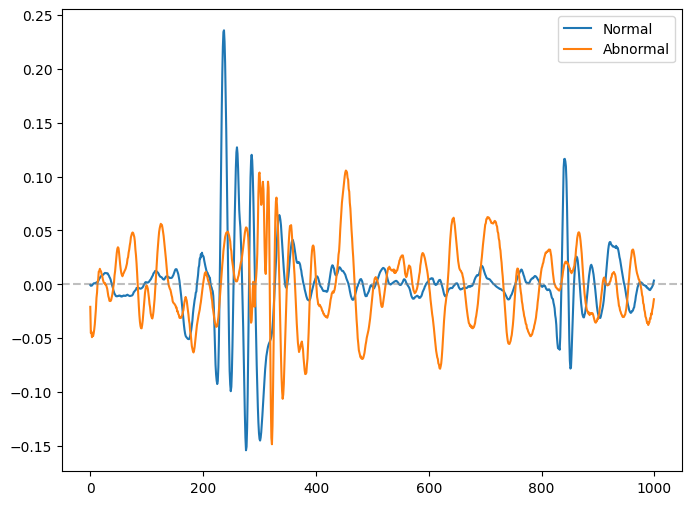

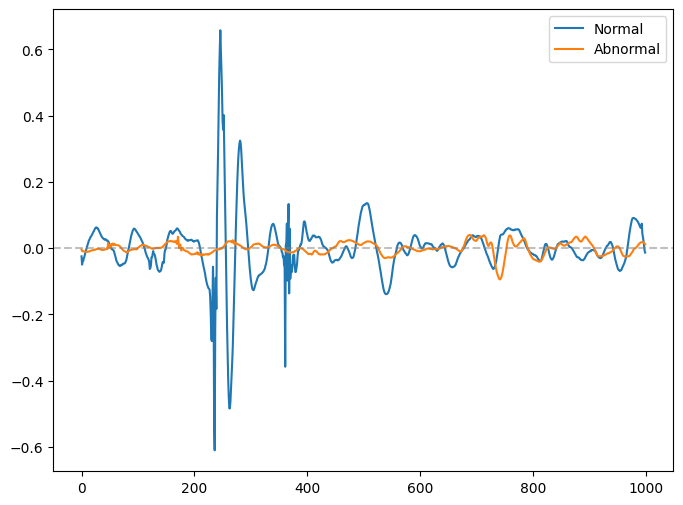

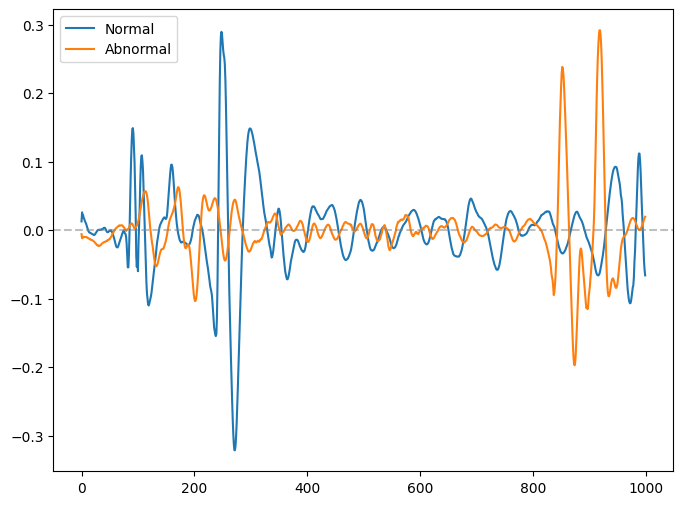

In [ ]:
# NOTE: Keeping this here in case we want to look at it again. This plots the first 1000 timestamps 
# of amplitudes of first 3 normal and abnormal patients
arff_file = arff.loadarff('/Users/muhammadkhalid/Desktop/f2025/STA395/project/AbnormalHeartbeat_TRAIN.arff')
df = pd.DataFrame(arff_file[0])
df['target'] = df['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')
abnormal = df.loc[df['target'] == 'Abnormal']
normal = df.loc[df['target'] == 'Normal']
for i in range(3):
    ab_x_first = abnormal.select_dtypes(include=['number']).T.iloc[:,i]
    n_x_first = normal.select_dtypes(include=['number']).T.iloc[:,i]
    plt.figure(figsize=(8,6))
    plt.plot(range(len(n_x_first))[0:1000], n_x_first[0:1000], label = 'Normal')
    plt.plot(range(len(ab_x_first))[0:1000], ab_x_first[0:1000], label = 'Abnormal')
    plt.axhline(y=0, color='gray', alpha = 0.5, linestyle='dashed')
    plt.legend()
    plt.show()

In [7]:
# train imbalance
cb_train = df_train.value_counts('target')/len(df_train)
cb_train

target
Abnormal    0.730392
Normal      0.269608
Name: count, dtype: float64

In [8]:
# load train set
arff_file = arff.loadarff('/Users/muhammadkhalid/Desktop/f2025/STA395/project/AbnormalHeartbeat_TRAIN.arff')
test = pd.DataFrame(arff_file[0])
test['target'] = test['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')

# test class imbalance
cb_test = test.value_counts('target')/len(df)
cb_test

target
Abnormal    0.730392
Normal      0.269608
Name: count, dtype: float64

In [9]:
# overall class imbalance
(cb_train + cb_test)/2

target
Abnormal    0.730392
Normal      0.269608
Name: count, dtype: float64